In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/test.csv.zip


# Preprocessing

In [4]:
import pandas as pd
import zipfile
import os

# Paths to zip files
zip_files = ["/kaggle/input/walmart-recruiting-store-sales-forecasting/features.csv.zip", 
             "/kaggle/input/walmart-recruiting-store-sales-forecasting/test.csv.zip", 
             "/kaggle/input/walmart-recruiting-store-sales-forecasting/train.csv.zip"]

# Unzip all files
for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("data")

# Load datasets
features = pd.read_csv("data/features.csv")
stores = pd.read_csv("/kaggle/input/walmart-recruiting-store-sales-forecasting/stores.csv")
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Quick data check
print(f"Features Shape: {features.shape}")
print(f"Stores Shape: {stores.shape}")
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Features Shape: (8190, 12)
Stores Shape: (45, 3)
Train Shape: (421570, 5)
Test Shape: (115064, 4)


In [5]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FeatureMerger(BaseEstimator, TransformerMixin):
    def __init__(self, feature_data, store_data):
        # Merge feature and store data on 'Store' column and convert 'Date' to datetime
        self.merged_features = feature_data.merge(store_data, how='inner', on='Store')
        self.merged_features['Date'] = pd.to_datetime(self.merged_features['Date'])

    def fit(self, X, y=None):
        # Fit function returns the transformer object itself
        return self

    def transform(self, X):
        # Copy input data to avoid modifying original data
        X_copy = X.copy()
        X_copy['Date'] = pd.to_datetime(X_copy['Date'])
        
        # Merge the input data with the pre-merged feature store
        merged_data = X_copy.merge(self.merged_features, how='inner', on=['Store', 'Date', 'IsHoliday'])
        
        # Sort the data by 'Date', 'Store', and 'Dept', then reset the index
        merged_data = merged_data.sort_values(by=['Date', 'Store', 'Dept']).reset_index(drop=True)
        
        return merged_data


In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()

        # Basic date parts extraction
        X_copy['Day'] = X_copy['Date'].dt.day
        X_copy['Month'] = X_copy['Date'].dt.month
        X_copy['Year'] = X_copy['Date'].dt.year

        # Extract ISO week and year for further feature engineering
        X_copy['Week'] = X_copy['Date'].dt.isocalendar().week
        X_copy['YearNum'] = X_copy['Date'].dt.year

        return X_copy


In [7]:
class HolidayFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Define holiday dates for Super Bowl, Labor Day, Thanksgiving, and Christmas
        self.superbowl = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        self.labor_day = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        self.thanksgiving = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        self.christmas = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()

        # Helper function to check if a date is in the same ISO week/year as a known holiday
        def is_holiday_week(date_series, holidays):
            holiday_weeks = set((d.isocalendar().week, d.year) for d in holidays)
            return date_series.apply(lambda d: (d.isocalendar().week, d.year) in holiday_weeks if pd.notnull(d) else False).astype(int)

        # Adding holiday features: Superbowl, Labor Day, Thanksgiving, and Christmas
        X_copy['SuperbowlWeek'] = is_holiday_week(X_copy['Date'], self.superbowl)
        X_copy['LaborDayWeek'] = is_holiday_week(X_copy['Date'], self.labor_day)
        X_copy['ThanksgivingWeek'] = is_holiday_week(X_copy['Date'], self.thanksgiving)
        X_copy['ChristmasWeek'] = is_holiday_week(X_copy['Date'], self.christmas)

        # Calculate days to Thanksgiving and Christmas for each row
        thanksgiving_dates = pd.to_datetime(X_copy['Year'].astype(str) + "-11-24")
        christmas_dates = pd.to_datetime(X_copy['Year'].astype(str) + "-12-24")

        X_copy['Days_to_Thanksgiving'] = (thanksgiving_dates - X_copy['Date']).dt.days
        X_copy['Days_to_Christmas'] = (christmas_dates - X_copy['Date']).dt.days

        # Drop the helper columns used for calculations
        X_copy = X_copy.drop(columns=['Week', 'YearNum'])

        return X_copy


In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class MissingDataImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Define columns for markdown and mean-based imputations
        self.markdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
        self.mean_columns = ['CPI', 'Unemployment']
        self.column_means = {}

    def fit(self, X, y=None):
        # Calculate mean values for the columns that require imputation
        for column in self.mean_columns:
            if column in X.columns:
                self.column_means[column] = X[column].mean()
        return self

    def transform(self, X):
        X_copy = X.copy()

        # Fill missing values in markdown columns with 0
        for column in self.markdown_columns:
            if column in X_copy.columns:
                X_copy[column] = X_copy[column].fillna(0.0)

        # Fill missing values in specified columns with their calculated mean
        for column in self.mean_columns:
            if column in X_copy.columns and column in self.column_means:
                X_copy[column] = X_copy[column].fillna(self.column_means[column])

        return X_copy


In [9]:
from sklearn.base import BaseEstimator, TransformerMixin

class CategoricalFeatureEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Define mappings for categorical variables
        self.type_conversion = {'A': 3, 'B': 2, 'C': 1}
        self.holiday_conversion = {False: 0, True: 1}

    def fit(self, X, y=None):
        # Nothing to fit in this transformer, simply return self
        return self

    def transform(self, X):
        X_copy = X.copy()

        # Encode 'Type' column using the predefined type_conversion mapping
        if 'Type' in X_copy.columns:
            X_copy['Type'] = X_copy['Type'].map(self.type_conversion)

        # Encode 'IsHoliday' column using the predefined holiday_conversion mapping
        if 'IsHoliday' in X_copy.columns:
            X_copy['IsHoliday'] = X_copy['IsHoliday'].map(self.holiday_conversion)

        return X_copy


In [10]:

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('merge', FeatureMerger(features, stores)),
    
    ('DateFeatureExtractor', DateFeatureExtractor()),
    ('HolidayFeatureAdder', HolidayFeatureAdder()),
    ('MissingDataImputer',MissingDataImputer()),
    ('CategoricalFeatureEncoder',CategoricalFeatureEncoder())
    ])
train_df = pipeline.fit_transform(train)


In [11]:
import pandas as pd

train_data = []
val_data = []

# Group the data by 'Store' and 'Dept', and split into train and validation sets
for (store_id, dept_id), subgroup in train_df.groupby(['Store', 'Dept']):
    subgroup_sorted = subgroup.sort_values('Date')
    split_index = int(len(subgroup_sorted) * 0.8)

    train_subgroup = subgroup_sorted.iloc[:split_index]
    val_subgroup = subgroup_sorted.iloc[split_index:]

    train_data.append(train_subgroup)
    val_data.append(val_subgroup)

# Combine all the train and validation subsets into final dataframes
train_df = pd.concat(train_data).reset_index(drop=True)
val_df = pd.concat(val_data).reset_index(drop=True)


In [12]:
train_df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Size,Day,Month,Year,SuperbowlWeek,LaborDayWeek,ThanksgivingWeek,ChristmasWeek,Days_to_Thanksgiving,Days_to_Christmas
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,151315,5,2,2010,0,0,0,0,292,322
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,151315,12,2,2010,1,0,0,0,285,315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,151315,19,2,2010,0,0,0,0,278,308
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,151315,26,2,2010,0,0,0,0,271,301
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,151315,5,3,2010,0,0,0,0,264,294


# Training

In [13]:
pip install pandas statsmodels matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
from statsmodels.tsa.arima.model import ARIMA


In [15]:
store= 1 
department= 1

sales_data = train_df[(train_df['Store']==store) & (train_df['Dept']==department)]['Weekly_Sales']

#fitting the model
model = ARIMA(sales_data, order= (1, 1, 1))
model_fit= model.fit()

In [16]:
forecast_steps = 12 
forecast = model_fit.forecast(steps = forecast_steps)

print(f"Forecasted sales for store {store} and department {department}: ")
display(forecast)

Forecasted sales for store 1 and department 1: 


114    43502.413009
115    35218.988565
116    30349.112948
117    27486.083451
118    25802.890995
119    24813.331911
120    24231.564107
121    23889.539276
122    23688.460797
123    23570.245536
124    23500.746066
125    23459.886904
Name: predicted_mean, dtype: float64

In [17]:
import matplotlib.pyplot as plt

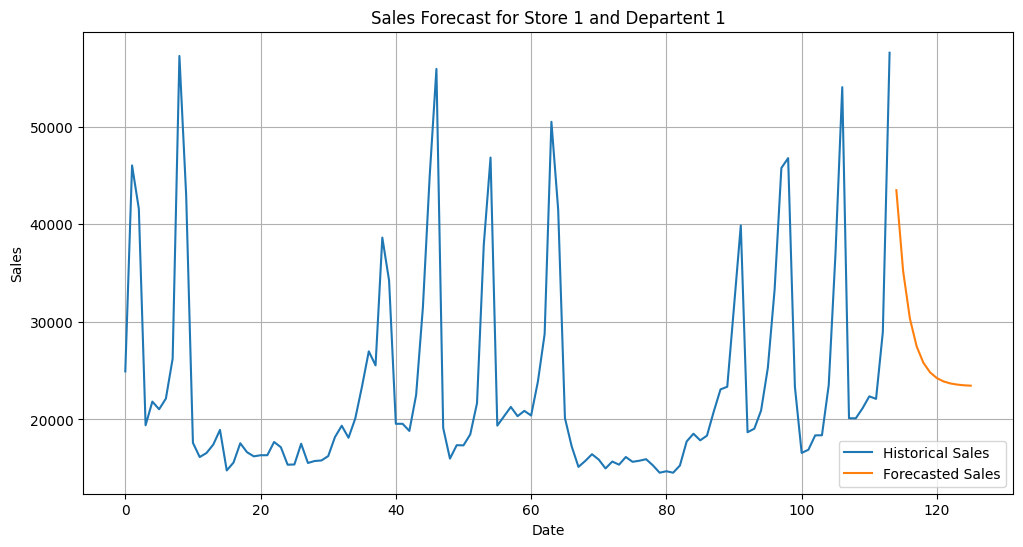

In [18]:
plt.figure(figsize=(12,6))
plt.plot(sales_data.index, sales_data.values, label ='Historical Sales')
plt.plot(forecast.index, forecast, label = 'Forecasted Sales')
plt.title(f"Sales Forecast for Store {store} and Departent {department}")
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
print(model_fit.summary())
# In-sample prediction
pred = model_fit.predict(start=sales_data.index[0], end=sales_data.index[-1])

# If needed, align index
pred = pred[:len(sales_data)]

# Calculate some metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(sales_data, pred)
mae = mean_absolute_error(sales_data, pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {mse**0.5:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1190.659
Date:                Tue, 08 Jul 2025   AIC                           2387.317
Time:                        17:43:51   BIC                           2395.500
Sample:                             0   HQIC                          2390.638
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5879      0.056     10.537      0.000       0.479       0.697
ma.L1         -0.9999      0.087    -11.543      0.000      -1.170      -0.830
sigma2      8.079e+07   1.08e-09   7.46e+16      0.0

In [20]:
!pip install dagshub mlflow
import dagshub
import mlflow
dagshub.init(repo_owner='TamariToradze', repo_name='ML-Final', mlflow=True)

Initialized MLflow to track repo "TamariToradze/ML-Final"

Repository TamariToradze/ML-Final initialized!

# Mlflow

In [24]:
import mlflow
import pickle
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

model_path = "arima_model.pkl"


with mlflow.start_run() as run:
    model_summary = str(model_fit.summary())
    mlflow.log_param("model_summary", model_summary)  # Log the model summary

    pred = model_fit.predict(start=sales_data.index[0], end=sales_data.index[-1])

    pred = pred[:len(sales_data)]

    mse = mean_squared_error(sales_data, pred)
    mae = mean_absolute_error(sales_data, pred)
    rmse = mse ** 0.5

    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

    with open(model_path, 'wb') as f:
        pickle.dump(model_fit, f)

    mlflow.log_artifact(model_path)

    print(f"Run ID: {run.info.run_id}")

    experiment_id = run.info.experiment_id
    tracking_uri = mlflow.get_tracking_uri()
    run_url = f"{tracking_uri}/#/experiments/{experiment_id}/runs/{run.info.run_id}"
    experiment_url = f"{tracking_uri}/#/experiments/{experiment_id}"

    print(f"🏃 View run at: {run_url}")
    print(f"🧪 View experiment at: {experiment_url}")


Mean Squared Error (MSE): 88728477.30
Root Mean Squared Error (RMSE): 9419.58
Mean Absolute Error (MAE): 5859.53
Run ID: 3699df4ceb064573a16d6c2fcf309f7f
🏃 View run at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0/runs/3699df4ceb064573a16d6c2fcf309f7f
🧪 View experiment at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0
🏃 View run bemused-penguin-534 at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0/runs/3699df4ceb064573a16d6c2fcf309f7f
🧪 View experiment at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0
